In [13]:
import pandas as pd
df = pd.read_csv('../data/Características y composición del hogar.csv', sep=';')
filtrado=df[df["P6040"]>=18]
filtrado

,DIRECTORIO,SECUENCIA_ENCUESTA,SECUENCIA_P,ORDEN,FEX_C,P6016,P1894,P6020,P6034,P6040,...,P1898,P1899,P3175,P1901,P1903,P1904,P1905,P1927,P3038,P3039
0,8369550,1,1,1,"472,1319014",1,3,2,1,45,...,10.0,5.0,7.0,10.0,6.0,0.0,7.0,6.0,1.0,2.0
1,8369550,2,1,2,"472,1319014",2,3,1,1,25,...,10.0,8.0,7.0,10.0,0.0,0.0,8.0,8.0,2.0,1.0
4,8369551,1,1,1,"308,8543189",1,3,2,1,62,...,7.0,4.0,7.0,8.0,6.0,2.0,8.0,7.0,1.0,2.0
5,8369552,1,1,1,"428,5162391",1,3,2,1,38,...,5.0,8.0,8.0,8.0,2.0,2.0,8.0,8.0,1.0,2.0
6,8369552,2,1,2,"428,5162391",2,3,1,1,49,...,5.0,8.0,8.0,8.0,2.0,3.0,8.0,8.0,2.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235344,8489520,1,1,1,"19,04352805",1,3,1,1,32,...,10.0,10.0,9.0,9.0,0.0,1.0,9.0,9.0,2.0,1.0
235345,8489520,2,1,2,"19,04352805",2,3,2,1,31,...,10.0,10.0,10.0,10.0,1.0,0.0,9.0,9.0,1.0,2.0
235347,8489521,1,1,1,"19,04352805",1,3,1,1,31,...,10.0,9.0,9.0,10.0,1.0,0.0,10.0,9.0,2.0,1.0
235348,8489521,2,1,2,"19,04352805",2,3,2,1,32,...,10.0,10.0,9.0,9.0,1.0,1.0,10.0,9.0,1.0,2.0


In [9]:
filtrado["P1895"].isna().sum()

np.int64(0)

In [10]:
filtrado["P6080"].isna().sum()

np.int64(0)

In [12]:
(~filtrado["P6080"].isin([1, 2, 3, 4, 5, 6])).sum()

np.int64(0)

In [11]:
(~filtrado["P1895"].isin([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10])).sum()

np.int64(0)

In [29]:
# MEDIDAS DESCRIPTIVAS EDAD (P6040)

print ("MEDIAS DISCRPTIVAS EDAD\n")

media_edad = filtrado["P6040"].mean()
print("Media edad:", media_edad)

mediana_edad = filtrado["P6040"].median()
print("Mediana edad:", mediana_edad)

minimo_edad = filtrado["P6040"].min()
print("Mínimo edad:", minimo_edad)

maximo_edad = filtrado["P6040"].max()
print("Máximo edad:", maximo_edad ,"\n")

# MEDIDAS DESCRIPTIVAS SATISFACCIÓN CON LA VIDA (P1895)

print ("MEDIAS DISCRPTIVAS SATISFACCIÓN CON LA VIDA\n")

media_satisfaccion = filtrado["P1895"].mean()
print("Media satisfacción con la vida:", media_satisfaccion)

mediana_satisfaccion = filtrado["P1895"].median()
print("Mediana satisfacción con la vida:", mediana_satisfaccion)

minimo_satisfaccion = filtrado["P1895"].min()
print("Mínimo satisfacción con la vida:", minimo_satisfaccion)

maximo_satisfaccion = filtrado["P1895"].max()
print("Máximo satisfacción con la vida:", maximo_satisfaccion,"\n")

# FRECUENCIAS EN CADA CATEGORIA

print ("FRECUENCIAS DE CADA CATEGORIA\n") 

#EDAD
frecuencia_sexo = filtrado["P6020"].value_counts().sort_index()
print("Frecuencia por sexo:")
print(frecuencia_sexo, '\n')

#SATISFACCION
frecuencia_etnia = filtrado["P6080"].value_counts().sort_index()
print("Frecuencia por etnia:")
print(frecuencia_etnia,'\n')

MEDIAS DISCRPTIVAS EDAD

Media edad: 45.84404592355762
Mediana edad: 44.0
Mínimo edad: 18
Máximo edad: 108 

MEDIAS DISCRPTIVAS SATISFACCIÓN CON LA VIDA

Media satisfacción con la vida: 8.142223514024124
Mediana satisfacción con la vida: 8.0
Mínimo satisfacción con la vida: 0.0
Máximo satisfacción con la vida: 10.0 

FRECUENCIAS DE CADA CATEGORIA

Frecuencia por sexo:
P6020
1    81044
2    90981
Name: count, dtype: int64 

Frecuencia por etnia:
P6080
1     18594
2        25
3       690
4        58
5     13499
6    139159
Name: count, dtype: int64 



Text(0.5, 1.0, 'Satisfacción con la vida')

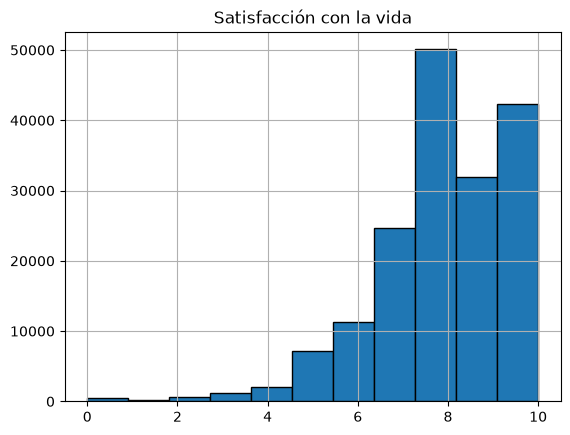

In [30]:
#HISTOGRAMA SATISFACCION
hist_sat = filtrado["P1895"].hist(bins=11, edgecolor="black") 
hist_sat.set_title("Satisfacción con la vida")

Text(0.5, 1.0, 'Edad')

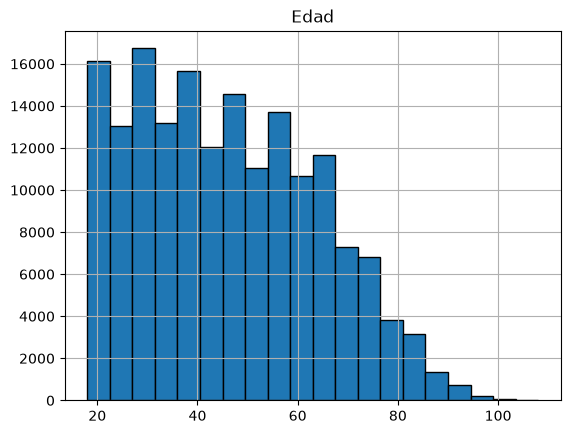

In [31]:
 #HISTOGRAMA EDAD
hist_edad=filtrado["P6040"].hist(bins=20, edgecolor="black")
hist_edad.set_title("Edad")

<Axes: title={'center': 'Distribución por sexo'}, xlabel='P6020'>

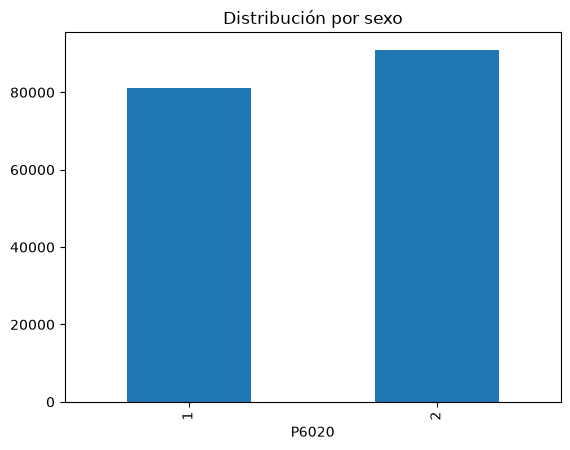

In [32]:
frecuencia_sexo.plot(kind="bar", title="Distribución por sexo") 

<Axes: title={'center': 'Autorreconocimiento étnico'}, xlabel='P6080'>

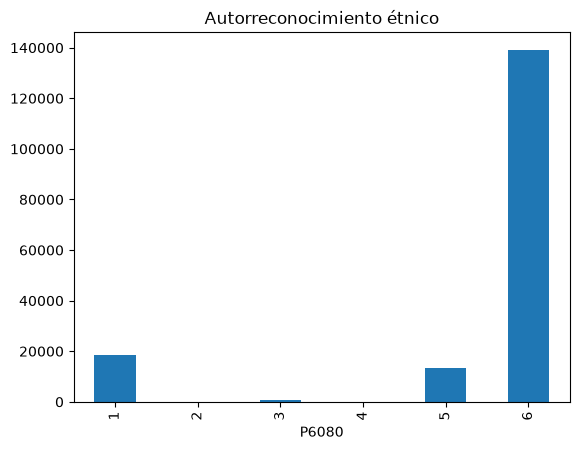

In [34]:
frecuencia_etnia.plot(kind="bar", title="Autorreconocimiento étnico") 

Text(0, 0.5, 'Satisfacción promedio (0 a 10)')

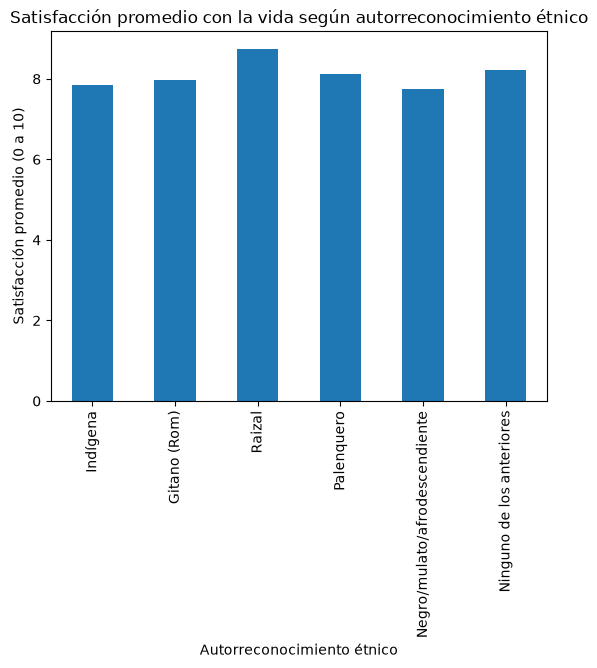

In [ ]:
etiquetas_etnia = {1:"Indígena", 2:"Gitano (Rom)", 3:"Raizal", 4:"Palenquero",
                    5:"Negro/mulato/afrodescendiente", 6:"Ninguno de los anteriores"}

filtrado["etnia"] = filtrado["P6080"].map(etiquetas_etnia)

satisfaccion_por_etnia = filtrado.groupby("etnia")["P1895"].mean().reindex(etiquetas_etnia.values())

graf = satisfaccion_por_etnia.plot(kind="bar", title="Satisfacción promedio con la vida según autorreconocimiento étnico")
graf.set_xlabel("Autorreconocimiento étnico")
graf.set_ylabel("Satisfacción promedio (0 a 10)")